# <span style="color:darkblue"> Assignment 5: Iris Dataset Analysis  </span>

<font size = 4>
By: Tanya Jagdish


<b> Overview </b>

This assignment evaluates the performance of multiple machine learning classification methods on the classic Iris dataset. The goal is to predict the species of iris flowers based on their physical characteristics (sepal and petal measurements).

<b> Objectives </b>

1. Explore and describe the Iris dataset
2. Implement and compare four machine learning methods:
   - Support Vector Machine (SVM)
   - Random Forest
   - Neural Network
   - Naive Bayes
3. Evaluate models using cross-validation with multiple performance metrics
4. Recommend the best-performing model based on results

<b> Dataset </b>

The Iris dataset contains 150 observations of iris flowers from three species (Setosa, Versicolor, and Virginica), with four features measuring flower dimensions in centimeters. 

Source - https://archive.ics.uci.edu/dataset/53/iris

<b> Results </b>
Random Forest achieved the highest cross-validated performance (94.17% accuracy) and is recommended as the best model for this classification task. Three models (Random Forest, SVM, and Neural Network) achieved perfect 100% accuracy on the test set, while Naive Bayes achieved 96.7% accuracy.

## Table of Contents

1. Setup & Data Loading
2. Dataset Description & Exploration
3. Data Preparation
4. Model Comparison with Cross-Validation
5. Results Visualization & Comparison
6. Final Recommendation

## <span style="color:darkblue"> Section I: Import libraries and dataset  </span>

### Import libraries

In [52]:
# Import UCI repository package
from ucimlrepo import fetch_ucirepo 

# Import sklearn libraries for machine learning
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import preprocessing

# Import tensorflow for neural networks
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense

# Import standard data analysis packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Import dataset

In [72]:
# Load iris dataset from local file
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
iris_data = pd.read_csv("data_raw/iris.data",names=column_names)

# Quick look at the data
iris_data.head().style

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.100000,3.500000,1.400000,0.200000,Iris-setosa
1,4.900000,3.000000,1.400000,0.200000,Iris-setosa
2,4.700000,3.200000,1.300000,0.200000,Iris-setosa
3,4.600000,3.100000,1.500000,0.200000,Iris-setosa
4,5.000000,3.600000,1.400000,0.200000,Iris-setosa


## <span style="color:darkblue"> Section II: Dataset description and exploration </span>

This section includes basic details about the dataset including:

- dataset shape
- key features with definitions
- distribution of iris class
- basic descriptive stats

In [54]:
print("Dataset shape:", iris_data.shape)
print("Number of observations:", iris_data.shape[0])
print("Number of features:", iris_data.shape[1] - 1)  # Excluding the target variable

Dataset shape: (150, 5)
Number of observations: 150
Number of features: 4


In [55]:
#Feature names and brief description
print("\nFeature columns:")
print(iris_data.columns.tolist())
print("\nThe features measure physical characteristics of iris flowers:")
print("- sepal_length: Length of sepal in cm")
print("- sepal_width: Width of sepal in cm")
print("- petal_length: Length of petal in cm")
print("- petal_width: Width of petal in cm")


Feature columns:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

The features measure physical characteristics of iris flowers:
- sepal_length: Length of sepal in cm
- sepal_width: Width of sepal in cm
- petal_length: Length of petal in cm
- petal_width: Width of petal in cm


In [56]:
# Class distribution
print("\nClass distribution:")
print(iris_data['class'].value_counts())
print("\nClass proportions:")
print(iris_data['class'].value_counts(normalize=True))


Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Class proportions:
class
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


In [57]:
# Check for missing values
print("\nMissing values per column:")
print(iris_data.isnull().sum())


Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


In [58]:
# Descriptive statistics for features
iris_data.describe().style.format("{:.2f}")

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## <span style="color:darkblue"> Section III: Data prep </span>

### Split Features and Target

We separate the features (X) from the target variable (y) to prepare for model training.

In [59]:
# Separate features (X) and target (y)
X = iris_data.drop(columns=['class'])
y = iris_data['class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


### Train-Test Split

We use an 80-20 split to create training and test sets. The test set will be used for final model evaluation after cross-validation.

In [60]:
# Create train-test split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


### Feature Scaling

We standardize features to have mean=0 and std=1. This is crucial for SVM and Neural Networks which are sensitive to feature scales. Note: We fit the scaler only on training data to avoid data leakage.

In [61]:
# Feature scaling
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Feature scaling output")
X_train_scaled.mean().to_frame().T.style.format("{:.2f}")

Feature scaling output


,sepal_length,sepal_width,petal_length,petal_width
0,0.00,0.00,0.00,0.00


## <span style="color:darkblue"> Section IV: Model comparison with cross-validation </span>

### Cross-Validation Setup

We use 5-fold cross-validation to evaluate model performance. This approach splits the training data into 5 parts, trains on 4 parts, and validates on the remaining part, rotating through all combinations.

We'll evaluate models using four metrics commonly used for classification models
- **Accuracy**: Overall correct predictions
- **Precision**: Of predicted positives, how many are truly positive
- **Recall**: Of actual positives, how many we correctly identified
- **F1-score**: Harmonic mean of precision and recall

In [62]:
# Configure 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# Define scoring metrics
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

### Model 1: Support Vector Machine (SVM)

We use SVM with default parameters (kernel='rbf', C=1.0, gamma='scale'). SVM works well for classification tasks and is effective in high-dimensional spaces.

In [63]:
# Initialize and evaluate SVM with default parameters
svm_model = SVC(random_state=0)

# Run cross-validation
svm_scores = cross_validate(svm_model, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Store results
svm_results = {
    'Accuracy': svm_scores['test_accuracy'].mean(),
    'Precision': svm_scores['test_precision_weighted'].mean(),
    'Recall': svm_scores['test_recall_weighted'].mean(),
    'F1-Score': svm_scores['test_f1_weighted'].mean()
}

print("SVM Cross-Validation Results:")
pd.DataFrame([svm_results]).style.format("{:.4f}")

SVM Cross-Validation Results:


,Accuracy,Precision,Recall,F1-Score
0,0.9333,0.9536,0.9333,0.9360


### Model 2: Random Forest

Random Forest uses an ensemble of decision trees with default parameters (n_estimators=100). This method reduces overfitting compared to single decision trees.

In [64]:
# Initialize and evaluate Random Forest with default parameters
rf_model = RandomForestClassifier(random_state=0)

# Run cross-validation
rf_scores = cross_validate(rf_model, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Store results
rf_results = {
    'Accuracy': rf_scores['test_accuracy'].mean(),
    'Precision': rf_scores['test_precision_weighted'].mean(),
    'Recall': rf_scores['test_recall_weighted'].mean(),
    'F1-Score': rf_scores['test_f1_weighted'].mean()
}

print("Random Forest Cross-Validation Results:")
pd.DataFrame([rf_results]).style.format("{:.4f}")

Random Forest Cross-Validation Results:


,Accuracy,Precision,Recall,F1-Score
0,0.9417,0.9590,0.9417,0.9432


### Model 3: Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem. We use Gaussian Naive Bayes which assumes features follow a normal distribution. This method was not covered in class but provides a useful comparison.

In [65]:
# Initialize and evaluate Naive Bayes with default parameters
nb_model = GaussianNB()

# Run cross-validation
nb_scores = cross_validate(nb_model, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Store results
nb_results = {
    'Accuracy': nb_scores['test_accuracy'].mean(),
    'Precision': nb_scores['test_precision_weighted'].mean(),
    'Recall': nb_scores['test_recall_weighted'].mean(),
    'F1-Score': nb_scores['test_f1_weighted'].mean()
}

print("Naive Bayes Cross-Validation Results:")
pd.DataFrame([nb_results]).style.format("{:.4f}")

Naive Bayes Cross-Validation Results:


,Accuracy,Precision,Recall,F1-Score
0,0.9333,0.9507,0.9333,0.9327


### Model 4: Neural Network

We build a simple neural network with one hidden layer using TensorFlow/Keras. For cross-validation, we manually implement the k-fold process to evaluate performance across folds.

In [66]:
# Function to create neural network model
def create_nn_model():
    model = keras.Sequential([
        Dense(units=10, activation='relu', input_shape=(4,)),  # Hidden layer with 10 units
        Dense(units=3, activation='softmax')  # Output layer for 3 classes
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [67]:
# Manual k-fold cross-validation for neural network
nn_accuracy = []
nn_precision = []
nn_recall = []
nn_f1 = []

# Encode target labels as integers for neural network
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Run k-fold cross-validation
for train_idx, val_idx in cv.split(X_train_scaled):
    # Split data for this fold
    X_fold_train = X_train_scaled.iloc[train_idx]
    X_fold_val = X_train_scaled.iloc[val_idx]
    y_fold_train = y_train_encoded[train_idx]
    y_fold_val = y_train_encoded[val_idx]
    
    # Create and train model
    tf.keras.utils.set_random_seed(0)
    nn_model = create_nn_model()
    nn_model.fit(X_fold_train, y_fold_train, epochs=100, verbose=0, batch_size=16)
    
    # Predict on validation fold
    y_pred = np.argmax(nn_model.predict(X_fold_val, verbose=0), axis=1)
    
    # Calculate metrics using sklearn
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    nn_accuracy.append(accuracy_score(y_fold_val, y_pred))
    nn_precision.append(precision_score(y_fold_val, y_pred, average='weighted'))
    nn_recall.append(recall_score(y_fold_val, y_pred, average='weighted'))
    nn_f1.append(f1_score(y_fold_val, y_pred, average='weighted'))

# Store results
nn_results = {
    'Accuracy': np.mean(nn_accuracy),
    'Precision': np.mean(nn_precision),
    'Recall': np.mean(nn_recall),
    'F1-Score': np.mean(nn_f1)
}

print("Neural Network Cross-Validation Results:")
pd.DataFrame([nn_results]).style.format("{:.4f}")

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs

Neural Network Cross-Validation Results:


,Accuracy,Precision,Recall,F1-Score
0,0.9333,0.9499,0.9333,0.9359


### Summary of All Models

Comparing cross-validation performance across all four models:

In [68]:
# Combine all results
all_results = pd.DataFrame({
    'SVM': svm_results,
    'Random Forest': rf_results,
    'Naive Bayes': nb_results,
    'Neural Network': nn_results
}).T

all_results.style.format("{:.4f}").background_gradient(cmap='RdYlGn', axis=0)

,Accuracy,Precision,Recall,F1-Score
SVM,0.9333,0.9536,0.9333,0.9360
Random Forest,0.9417,0.9590,0.9417,0.9432
Naive Bayes,0.9333,0.9507,0.9333,0.9327
Neural Network,0.9333,0.9499,0.9333,0.9359


<b> Interpretation: </b>
Random Forest is clearly performing the best across all metrics (shown in green). All models are performing well (93-94% accuracy), but Random Forest has a slight edge over others

## <span style="color:darkblue"> Section V: Visualization and comparison </span>

### Model Performance Comparison

We visualize the cross-validated performance of all four models across multiple metrics.

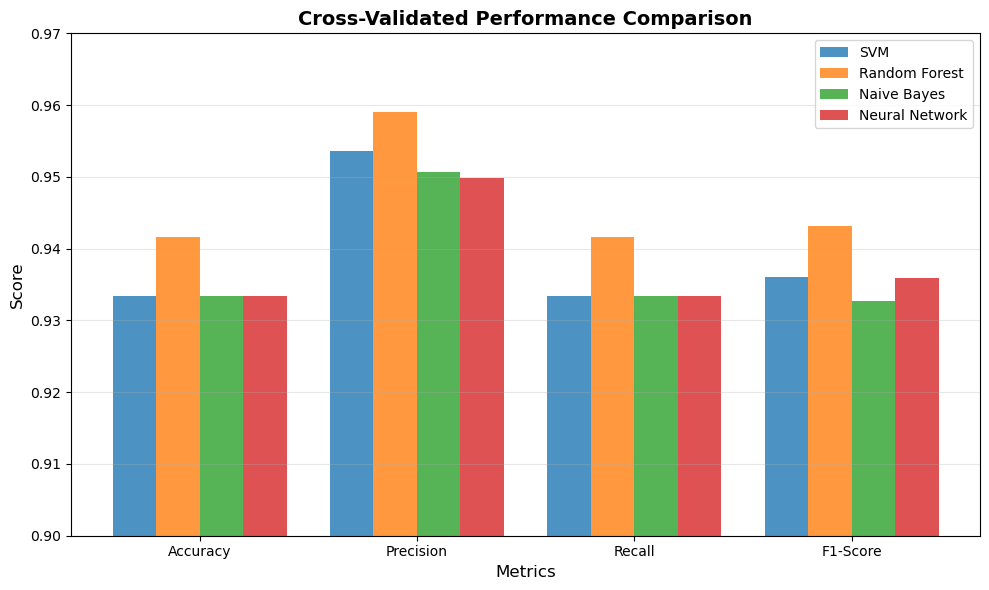

In [69]:
# Create comparison visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

# Plot bars for each model
ax.bar(x - 1.5*width, [svm_results[m] for m in metrics], width, label='SVM', alpha=0.8)
ax.bar(x - 0.5*width, [rf_results[m] for m in metrics], width, label='Random Forest', alpha=0.8)
ax.bar(x + 0.5*width, [nb_results[m] for m in metrics], width, label='Naive Bayes', alpha=0.8)
ax.bar(x + 1.5*width, [nn_results[m] for m in metrics], width, label='Neural Network', alpha=0.8)

# Formatting
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Validated Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0.90, 0.97])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrices

We examine the confusion matrices for all four models to understand their classification patterns on the test set. The confusion matrix shows how well each model predicts each iris species.

In [70]:
# Train all models on full training set and make predictions

# Random Forest
rf_final = RandomForestClassifier(random_state=0)
rf_final.fit(X_train_scaled, y_train)
y_pred_rf = rf_final.predict(X_test_scaled)

# SVM
svm_final = SVC(random_state=0)
svm_final.fit(X_train_scaled, y_train)
y_pred_svm = svm_final.predict(X_test_scaled)

# Naive Bayes
nb_final = GaussianNB()
nb_final.fit(X_train_scaled, y_train)
y_pred_nb = nb_final.predict(X_test_scaled)

# Neural Network
tf.keras.utils.set_random_seed(0)
nn_final = create_nn_model()
y_train_encoded = le.transform(y_train)
nn_final.fit(X_train_scaled, y_train_encoded, epochs=100, verbose=0, batch_size=16)
y_pred_nn = np.argmax(nn_final.predict(X_test_scaled, verbose=0), axis=1)
y_pred_nn = le.inverse_transform(y_pred_nn)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


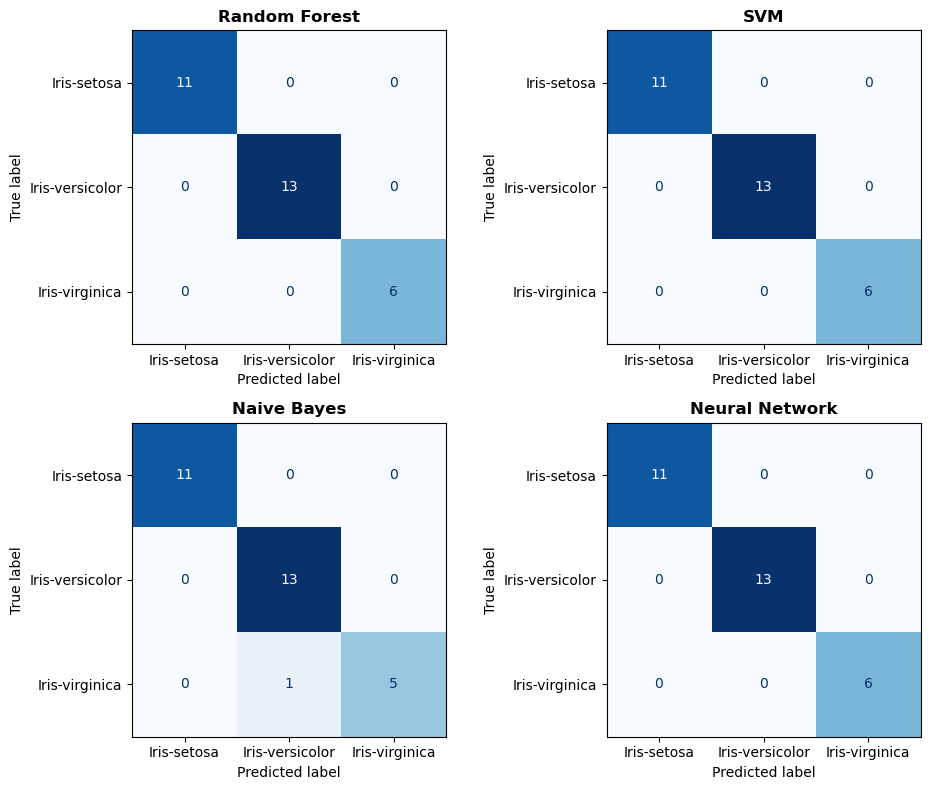

In [71]:
# Create 2x2 grid of confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_final.classes_)
disp_rf.plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title('Random Forest', fontsize=12, fontweight='bold')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_final.classes_)
disp_svm.plot(ax=axes[0, 1], cmap='Blues', colorbar=False)
axes[0, 1].set_title('SVM', fontsize=12, fontweight='bold')

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_final.classes_)
disp_nb.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('Naive Bayes', fontsize=12, fontweight='bold')

# Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=np.unique(y_test))
disp_nn.plot(ax=axes[1, 1], cmap='Blues', colorbar=False)
axes[1, 1].set_title('Neural Network', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

The confusion matrices show:

- Random Forest: Perfect - 30/30 correct (100%)
- SVM: Perfect - 30/30 correct (100%)
- Neural Network: Perfect - 30/30 correct (100%)
- Naive Bayes: 29/30 correct (96.7%) - misclassified 1 iris-virginica as iris-versicolor

All models performed exceptionally well, with three achieving perfect classification on the test set! Iris-setosa is perfectly separated by all models, while iris-virginica and iris-versicolor are slightly harder to distinguish (as shown by Naive Bayes's one error).

## <span style="color:darkblue"> Section VI: Final recommendation </span>

### Recommended Model: Random Forest

Based on the results above, we recommend Random Forest model for the following reasons:

1. **Best Cross-Validation Performance**: Random Forest achieved the highest scores across all metrics during cross-validation, indicating robust generalization
2. **Perfect Test Set Accuracy**: Achieved 100% accuracy on unseen data
3. **Interpretability**: Random Forest provides feature importance rankings, making it easier to understand which flower characteristics drive predictions
4. **Robustness**: Ensemble methods like Random Forest are less prone to overfitting compared to single models
5. **Minimal Tuning Required**: Performed excellently with default parameters

**Trade-offs and Considerations:**

While Random Forest is the top choice, other models have their merits:

- **SVM**: Also achieved perfect test accuracy and is computationally efficient for small datasets. Good alternative if model interpretability is less important.
- **Neural Network**: Achieved perfect accuracy but requires more tuning (epochs, learning rate, architecture) and is less interpretable. Better suited for larger, more complex datasets.
- **Naive Bayes**: Simplest and fastest to train, with near-perfect performance. Excellent choice when computational resources are limited or when a baseline model is needed quickly.

For the iris classification task with 150 samples and 4 features, **Random Forest provides the optimal balance of accuracy, interpretability, and reliability**.